# Construction of explaining networks:
(a) Implement the BIC-cherry+expansion algorithm for given graphs $(G, \sigma)$ as in the tech report from Patricia Ebert and Marc Hellmuth.

(b) Modify this algorithm by restricting expansions $[xy : xz]$ to accepting edges $xz$ in graph $(G, σ)$ and possibly relabel $qxz$ as $pxz$

(c) Thoroughly test these algorithms! Think of unit tests for your implementations!

(d) Test if variant (b) always yields an explanation for weak best matches: to this end, generate a network $(N, σ)$, compute its weak best match graph, run variant (b) to produce an explaining network $(N , σ)$, and check that the weak best match graph of $(N', σ)$ coincides with the weak best match graph of $(N, σ)$. If this turns out to be not true, find the minimal examples where the networks differ.

## Generating example BMG from paper as starting graph
Using the right hand network of figure 2 as a starting point.
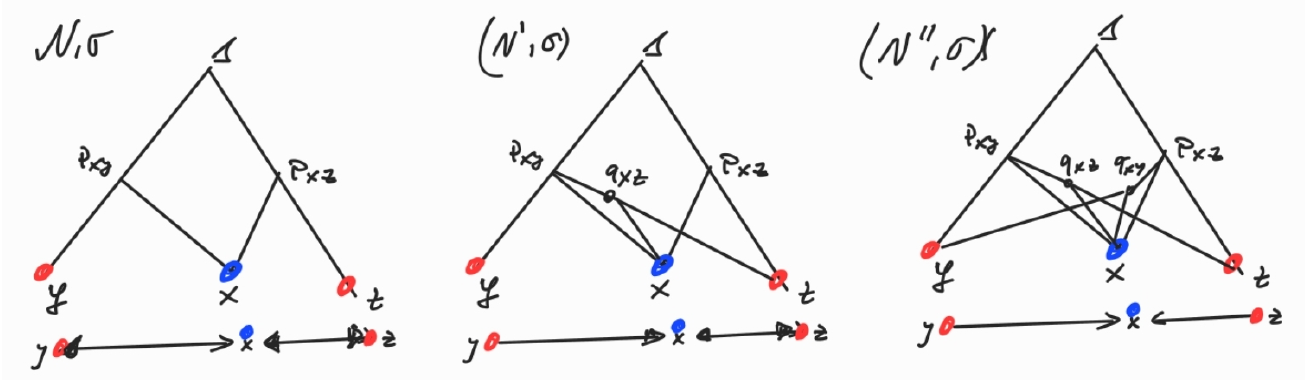
**Figure 2**: Left, a BIC-cherry network N with leaf set $X = {x, y, z}$ and leaf coloring $σ (x) ̸= σ (y) = σ (z)$. The BMG $G(N, σ )$ is shown directly below $(N, σ )$. In $G(N, σ )$, all arcs between all pairs of vertices of different colors are present. Right, the BMG $G(N', σ )$, drawn below $(N', σ )$, differs from $G(N, σ )$ only by the absence of the single arc $(x, y)$. Here, $N'$ coincides with the extension of $N$ by $[xy : xz]$.

In [33]:
# Importing step
import networkx as nx
import BICcherry
from networkx.drawing.nx_pydot import graphviz_layout
import matplotlib.pyplot as plt
from bmg_Tony import bmg

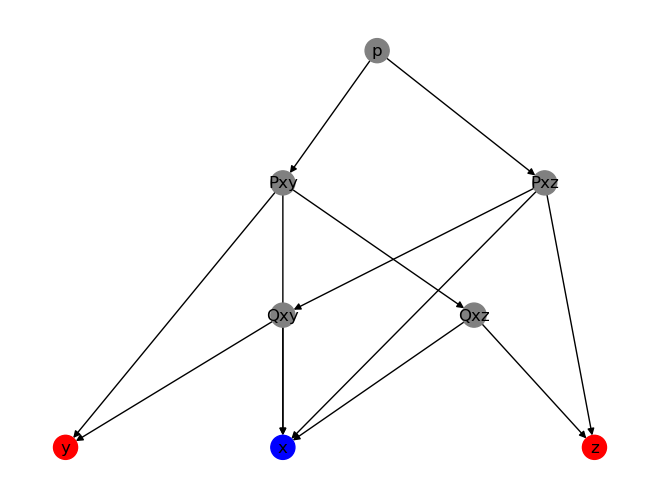

In [2]:
# Creating network for the BMG
bic_cherry = nx.DiGraph()
bic_cherry.add_nodes_from([("y", {"color": "red"}), ("x", {"color": "blue"}), ("z", {"color": "red"})])
bic_cherry.add_edges_from([("p", "Pxy"), ("Pxy", "y"), ("Pxy", "x"), ("Pxy", "Qxz"), ("Qxz", "x"), ("Qxz", "z"),
                               ("p", "Pxz"), ("Pxz", "z"), ("Pxz", "x"), ("Pxz", "Qxy"), ("Qxy", "x"), ("Qxy", "y")])

nodes_list = [v for v in bic_cherry.nodes()]
nodes_colors = [bic_cherry.nodes[v].get("color", "grey") for v in nodes_list]

# draw network
pos = graphviz_layout(bic_cherry, prog="dot")
nx.draw(bic_cherry, pos, nodelist=nodes_list, node_color=nodes_colors, with_labels=True)


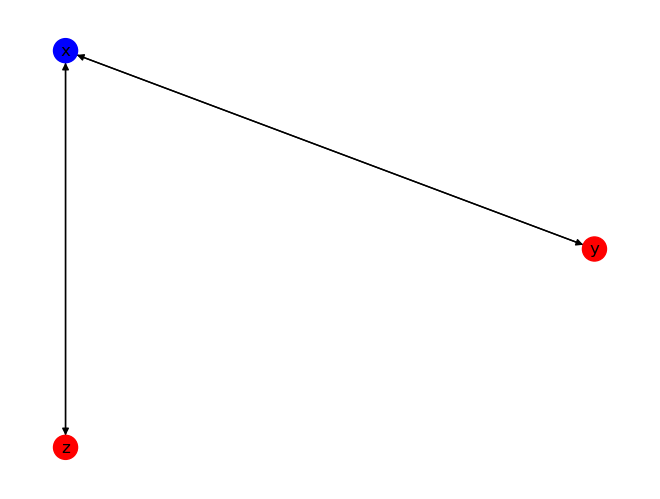

In [3]:
# Generate weak best match graph from network and draw it
G = bmg(bic_cherry, mode="weak")

# draw BMG
nodes_list = [v for v in G.nodes()]
nodes_colors = [G.nodes[v].get("color", "grey") for v in nodes_list]

# draw BMG
nx.draw(G, nx.circular_layout(G), nodelist=nodes_list, node_color=nodes_colors, with_labels=True)

In [4]:
# generating BIC cherry
bic_cherry_tree = BICcherry.BICcherry(G)

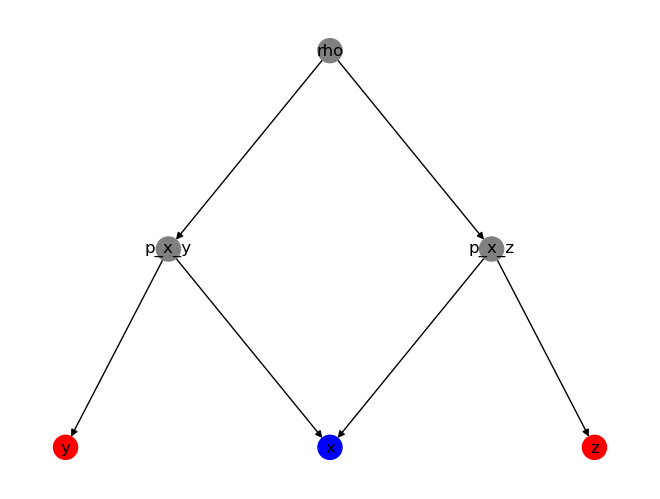

In [5]:
# Visualizing BIC cherry network
nodes_list = [v for v in bic_cherry_tree.nodes()]
nodes_colors = [bic_cherry_tree.nodes[v].get("color", "grey") for v in nodes_list]
fig = plt.figure()
pos = graphviz_layout(bic_cherry_tree, prog="dot")
nx.draw(bic_cherry_tree, pos, nodelist=nodes_list, node_color= nodes_colors, with_labels = True)


In [6]:
# Checking that weak BMG is the same as original graph
BMG = bmg(bic_cherry_tree, mode="weak")
print("Edges in weak BMG: ", BMG.edges(data=True))
print("Edges in original graph", G.edges(data=True))
print("The weak BMG and the original graph are equal: ", nx.utils.graphs_equal(G, BMG))

Edges in weak BMG:  [('x', 'y', {}), ('x', 'z', {}), ('y', 'x', {}), ('z', 'x', {})]
Edges in original graph [('y', 'x', {}), ('x', 'y', {}), ('x', 'z', {}), ('z', 'x', {})]
The weak BMG and the original graph are equal:  True


In [7]:
# Checking that strong BMG is the same as original graph
BMG = bmg(bic_cherry_tree, mode="strong")
print("Edges in strong BMG: ", BMG.edges(data=True))
print("Edges in original graph", G.edges(data=True))
print("The strong BMG and the original graph are equal: ", nx.utils.graphs_equal(G, BMG))

Edges in strong BMG:  [('x', 'y', {}), ('x', 'z', {}), ('y', 'x', {}), ('z', 'x', {})]
Edges in original graph [('y', 'x', {}), ('x', 'y', {}), ('x', 'z', {}), ('z', 'x', {})]
The strong BMG and the original graph are equal:  True


### Results
Both strong and weak definitions give the same BMGs from the network that was generated from the weak definition.

## Generating second example BMG from paper
This time, we choose the left side network from figure 2 as a starting point.

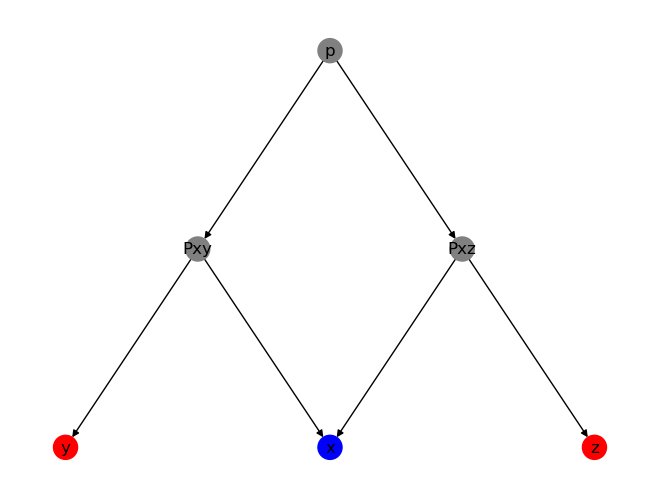

In [8]:
# Creating network for the BMG
bic_cherry = nx.DiGraph()
bic_cherry.add_nodes_from([("y", {"color": "red"}), ("x", {"color": "blue"}), ("z", {"color": "red"})])
bic_cherry.add_edges_from([("p", "Pxy"), ("Pxy", "y"), ("Pxy", "x"), 
                               ("p", "Pxz"), ("Pxz", "z"), ("Pxz", "x")])

nodes_list = [v for v in bic_cherry.nodes()]
nodes_colors = [bic_cherry.nodes[v].get("color", "grey") for v in nodes_list]

# draw network
pos = graphviz_layout(bic_cherry, prog="dot")
nx.draw(bic_cherry, pos, nodelist=nodes_list, node_color=nodes_colors, with_labels=True)

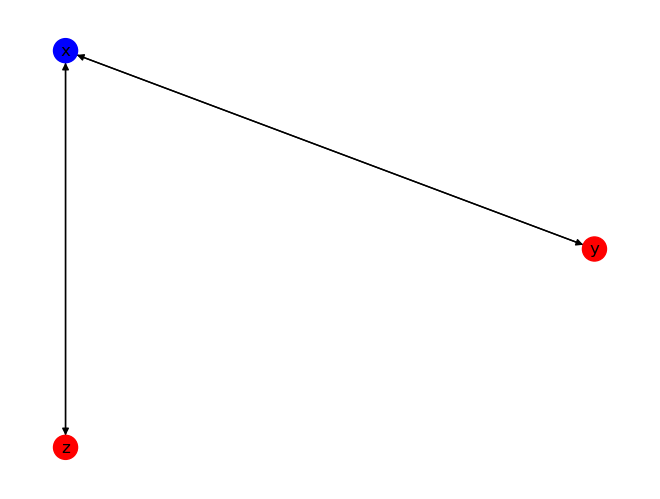

In [9]:
# Generate weak best match graph from network and draw it
G = bmg(bic_cherry, mode="weak")

# draw BMG
nodes_list = [v for v in G.nodes()]
nodes_colors = [G.nodes[v].get("color", "grey") for v in nodes_list]

# draw BMG
nx.draw(G, nx.circular_layout(G), nodelist=nodes_list, node_color=nodes_colors, with_labels=True)

In [10]:
# generating BIC cherry
bic_cherry_tree = BICcherry.BICcherry(G)

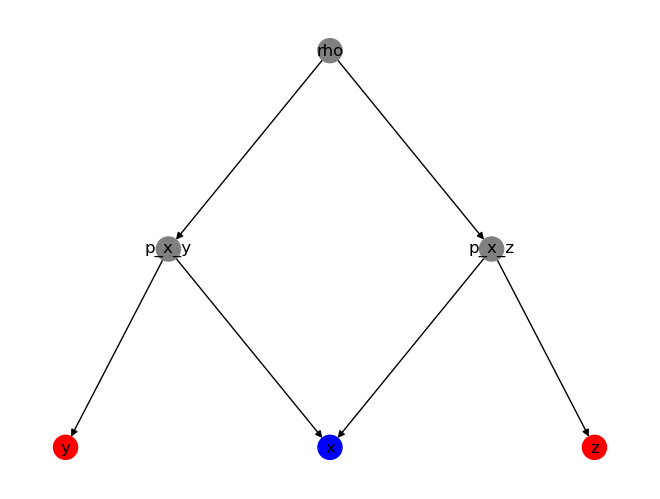

In [11]:
# Visualizing BIC cherry network
nodes_list = [v for v in bic_cherry_tree.nodes()]
nodes_colors = [bic_cherry_tree.nodes[v].get("color", "grey") for v in nodes_list]
fig = plt.figure()
pos = graphviz_layout(bic_cherry_tree, prog="dot")
nx.draw(bic_cherry_tree, pos, nodelist=nodes_list, node_color= nodes_colors, with_labels = True)

In [12]:
# Checking that weak BMG is the same as original graph
BMG = bmg(bic_cherry_tree, mode="weak")
print("Edges in weak BMG: ", BMG.edges(data=True))
print("Edges in original graph", G.edges(data=True))
print("The weak BMG and the original graph are equal: ", nx.utils.graphs_equal(G, BMG))

Edges in weak BMG:  [('x', 'y', {}), ('x', 'z', {}), ('y', 'x', {}), ('z', 'x', {})]
Edges in original graph [('y', 'x', {}), ('x', 'y', {}), ('x', 'z', {}), ('z', 'x', {})]
The weak BMG and the original graph are equal:  True


In [13]:
# Checking that strong BMG is the same as original graph
BMG = bmg(bic_cherry_tree, mode="strong")
print("Edges in strong BMG: ", BMG.edges(data=True))
print("Edges in original graph", G.edges(data=True))
print("The strong BMG and the original graph are equal: ", nx.utils.graphs_equal(G, BMG))

Edges in strong BMG:  [('x', 'y', {}), ('x', 'z', {}), ('y', 'x', {}), ('z', 'x', {})]
Edges in original graph [('y', 'x', {}), ('x', 'y', {}), ('x', 'z', {}), ('z', 'x', {})]
The strong BMG and the original graph are equal:  True


### Results
Again, the two definitions give the same BMGs, and both are equal to the original BMG. However, here the networks (starting and generated) are identical as well.

## Generating example BMG from figure 3 of the paper
Using the left hand graph (BMG) of figure 3. Note that the colors in the network on the right side were swapped.
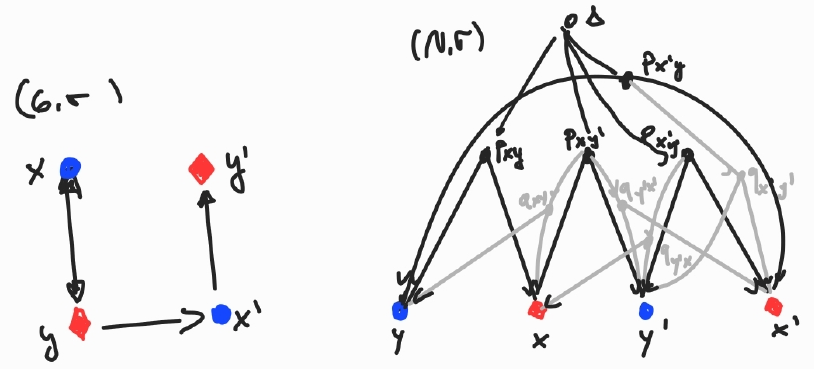

**Figure 3**: A BMG $(G, σ )$ that is explained by $(N, σ )$. Extension of the underlying BIC-cherry network are highlighted in gray. Note that $(G, σ )$ cannot be explained by a tree $(T, σ )$. To see this, assume that $(G, σ )$ is explained by $(T, σ )$. In this case, $lca_T (y' , x)$ and $lca_T (y' , x')$ are well-defined and ⪯T -comparable, i.e., at least one of the vertices x and x′
must be a best match of $y'$ . However, no arc $(y' , x)$ and $(y' , x')$ exists in $(G, σ )$.

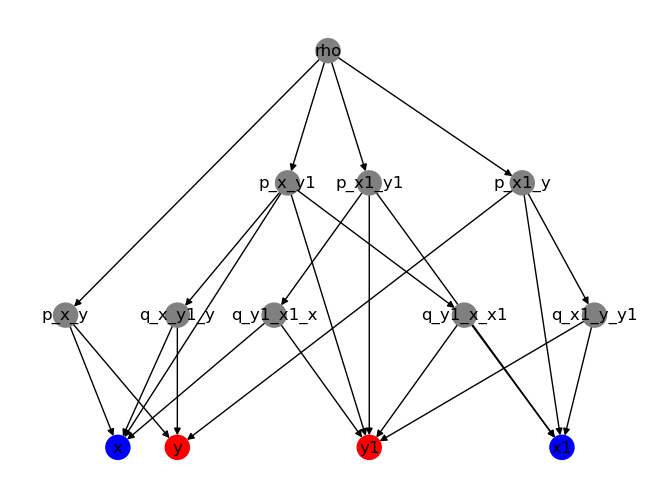

In [14]:
# Creating network for the BMG
bic_cherry = nx.DiGraph()
bic_cherry.add_nodes_from([("y", {"color": "red"}), ("x", {"color": "blue"}), ("y1", {"color": "red"}), ("x1", {"color": "blue"})])
bic_cherry.add_edges_from([('rho', 'p_x_y'), ('rho', 'p_x_y1'), ('rho', 'p_x1_y'), ('rho', 'p_x1_y1'), ('p_x_y', 'x'), 
                           ('p_x_y', 'y'), ('p_x_y1', 'x'), ('p_x_y1', 'y1'), ('p_x_y1', 'q_x_y1_y'), ('p_x_y1', 'q_y1_x_x1'), 
                           ('p_x1_y', 'x1'), ('p_x1_y', 'y'), ('p_x1_y', 'q_x1_y_y1'), ('p_x1_y1', 'x1'), ('p_x1_y1', 'y1'), 
                           ('p_x1_y1', 'q_y1_x1_x'), ('q_x_y1_y', 'x'), ('q_x_y1_y', 'y'), ('q_y1_x_x1', 'y1'), ('q_y1_x_x1', 'x1'), 
                           ('q_x1_y_y1', 'x1'), ('q_x1_y_y1', 'y1'), ('q_y1_x1_x', 'y1'), ('q_y1_x1_x', 'x')])

nodes_list = [v for v in bic_cherry.nodes()]
nodes_colors = [bic_cherry.nodes[v].get("color", "grey") for v in nodes_list]

# draw network
pos = graphviz_layout(bic_cherry, prog="dot")
nx.draw(bic_cherry, pos, nodelist=nodes_list, node_color=nodes_colors, with_labels=True)

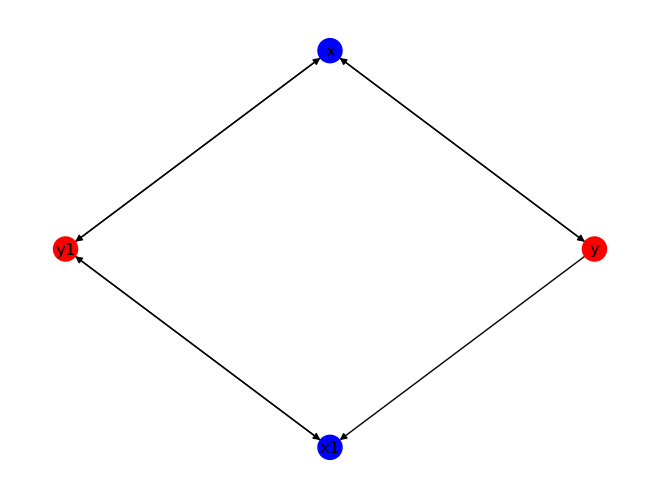

In [15]:
# Generate weak best match graph from network and draw it
G = bmg(bic_cherry, mode="weak")

# draw BMG
nodes_list = [v for v in G.nodes()]
nodes_colors = [G.nodes[v].get("color", "grey") for v in nodes_list]

# draw BMG
nx.draw(G, nx.circular_layout(G), nodelist=nodes_list, node_color=nodes_colors, with_labels=True)

In [16]:
# generating BIC cherry
bic_cherry_tree = BICcherry.BICcherry(G)

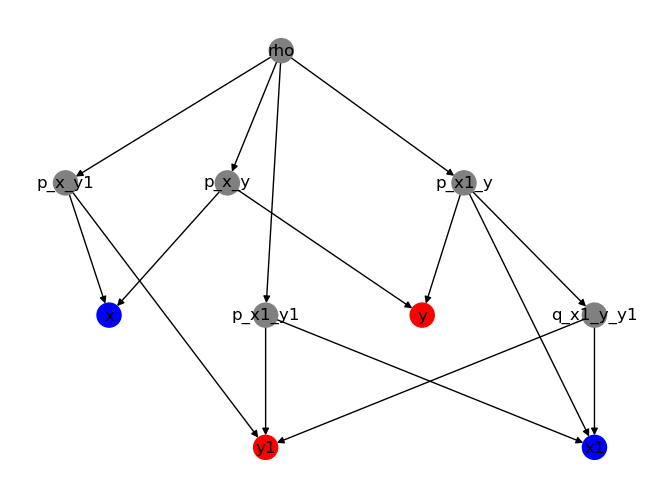

In [17]:
# Visualizing BIC cherry network
nodes_list = [v for v in bic_cherry_tree.nodes()]
nodes_colors = [bic_cherry_tree.nodes[v].get("color", "grey") for v in nodes_list]
fig = plt.figure()
pos = graphviz_layout(bic_cherry_tree, prog="dot")
nx.draw(bic_cherry_tree, pos, nodelist=nodes_list, node_color= nodes_colors, with_labels = True)

In [18]:
# Checking that weak BMG is the same as original graph
BMG = bmg(bic_cherry_tree, mode="weak")
print("Edges in weak BMG: ", BMG.edges(data=True))
print("Edges in original graph", G.edges(data=True))
print("The weak BMG and the original graph are equal: ", nx.utils.graphs_equal(G, BMG))

Edges in weak BMG:  [('x', 'y', {}), ('x', 'y1', {}), ('y', 'x', {}), ('y', 'x1', {}), ('y1', 'x', {}), ('y1', 'x1', {}), ('x1', 'y1', {})]
Edges in original graph [('y', 'x', {}), ('y', 'x1', {}), ('x', 'y', {}), ('x', 'y1', {}), ('y1', 'x', {}), ('y1', 'x1', {}), ('x1', 'y1', {})]
The weak BMG and the original graph are equal:  True


In [19]:
# Checking that strong BMG is the same as original graph
BMG = bmg(bic_cherry_tree, mode="strong")
print("Edges in strong BMG: ", BMG.edges(data=True))
print("Edges in original graph", G.edges(data=True))
print("The strong BMG and the original graph are equal: ", nx.utils.graphs_equal(G, BMG))

Edges in strong BMG:  [('x', 'y', {}), ('x', 'y1', {}), ('y', 'x', {}), ('y', 'x1', {}), ('y1', 'x', {}), ('y1', 'x1', {}), ('x1', 'y1', {})]
Edges in original graph [('y', 'x', {}), ('y', 'x1', {}), ('x', 'y', {}), ('x', 'y1', {}), ('y1', 'x', {}), ('y1', 'x1', {}), ('x1', 'y1', {})]
The strong BMG and the original graph are equal:  True


### Results
Again, both the strong and the weak definition result in the same BMG that still explains the BIC Cherry + Extension network. However, it appears that there is an error in figure 3. The BMG on the left hand side is not explained by the network on the right hand side (with neither the weak nor the strong definition).

### Counter example:
However, if we use that BMG as a starting point, the BIC Cherry + Extension algorithm indeed gives aus the network we see in the figure on the right hand side, and then we don't get the correct BMGs back. However, was that BMG derived from a network?

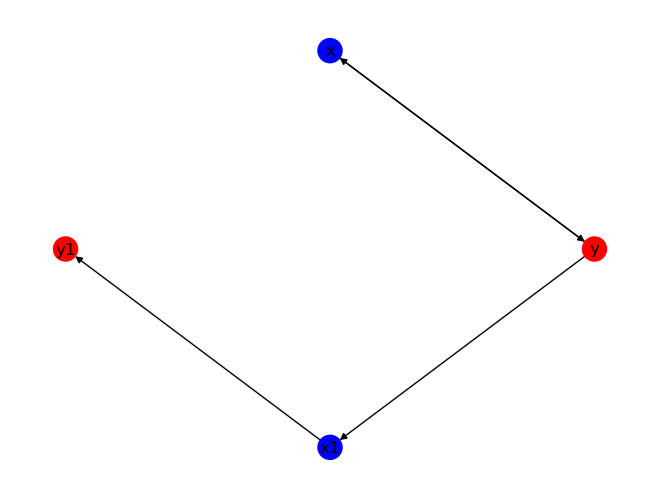

In [20]:
# Creating BMG
G = nx.DiGraph()
G.add_nodes_from([("y", {"color": "red"}), ("x", {"color": "blue"}), ("y1", {"color": "red"}), ("x1", {"color": "blue"})])
G.add_edges_from([("y", "x"), ("x", "y"), ("y", "x1"), ("x1", "y1")])
nodes_list = [v for v in G.nodes()]
nodes_colors = [G.nodes[v].get("color", "grey") for v in nodes_list]

# draw BMG
nx.draw(G, nx.circular_layout(G), nodelist=nodes_list, node_color=nodes_colors, with_labels=True)

In [21]:
# generating BIC cherry
bic_cherry_tree = BICcherry.BICcherry(G)

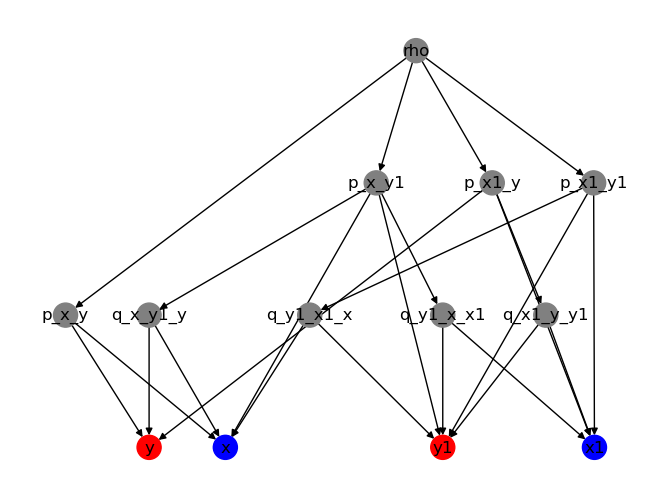

In [22]:
# Visualizing BIC cherry network
nodes_list = [v for v in bic_cherry_tree.nodes()]
nodes_colors = [bic_cherry_tree.nodes[v].get("color", "grey") for v in nodes_list]
fig = plt.figure()
pos = graphviz_layout(bic_cherry_tree, prog="dot")
nx.draw(bic_cherry_tree, pos, nodelist=nodes_list, node_color= nodes_colors, with_labels = True)

In [23]:
# Checking that weak BMG is the same as original graph
BMG = bmg(bic_cherry_tree, mode="weak")
print("Edges in weak BMG: ", BMG.edges(data=True))
print("Edges in original graph", G.edges(data=True))
print("The weak BMG and the original graph are equal: ", nx.utils.graphs_equal(G, BMG))

Edges in weak BMG:  [('x', 'y', {}), ('x', 'y1', {}), ('y', 'x', {}), ('y', 'x1', {}), ('y1', 'x', {}), ('y1', 'x1', {}), ('x1', 'y1', {})]
Edges in original graph [('y', 'x', {}), ('y', 'x1', {}), ('x', 'y', {}), ('x1', 'y1', {})]
The weak BMG and the original graph are equal:  False


In [24]:
# Checking that strong BMG is the same as original graph
BMG = bmg(bic_cherry_tree, mode="strong")
print("Edges in strong BMG: ", BMG.edges(data=True))
print("Edges in original graph", G.edges(data=True))
print("The strong BMG and the original graph are equal: ", nx.utils.graphs_equal(G, BMG))

Edges in strong BMG:  [('x', 'y', {}), ('y', 'x', {}), ('x1', 'y1', {})]
Edges in original graph [('y', 'x', {}), ('y', 'x1', {}), ('x', 'y', {}), ('x1', 'y1', {})]
The strong BMG and the original graph are equal:  False


### Results
As we can see, in this case neither the strong nor the weak definition give us the correct BMG graph back (the one that we initialized the BIC cherry + extension from). Is this because there might not be a "correct" or "regular phylogenetic" network that this BMG can be derived from, or is there some other issue here?

I am also not 100% clear why the edge $(y, x1)$ is missing in the strong definition. $lca(y,x1) = \{p\_x1\_y,\cdots\}$ und dieser erste lca ist nicht kompatibel mit den $lca(y,x) = \{p\_x\_y, q\_x\_y1\_y\}$.

Trial of making an explaining network intuitively (Max):

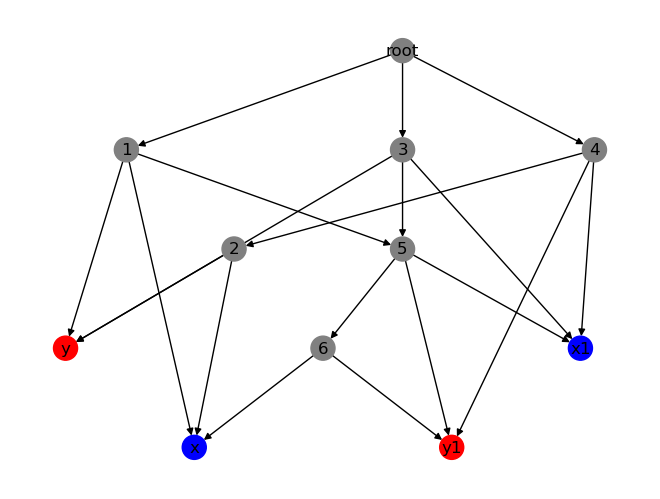

In [30]:
# Creating BMG
G = nx.DiGraph()
G.add_nodes_from([("y", {"color": "red"}), ("x", {"color": "blue"}), ("y1", {"color": "red"}), ("x1", {"color": "blue"}), "root", "1", "2", "3", "4", "5", "6"])
G.add_edges_from([("root", "1"), ("root", "4"), ("root", "3"), 
                  ("1", "y"), ("1", "x"), ("1", "5"), 
                  ("2", "x"), ("2", "y"), 
                  ("3", "y"), ("3", "x1"), ("3", "5"), 
                  ("4", "y1"), ("4", "2"), ("4", "x1"), 
                  ("5", "x1"), ("5", "y1"), ("5", "6"), 
                  ("6", "x"), ("6", "y1")])
nodes_list = [v for v in G.nodes()]
nodes_colors = [G.nodes[v].get("color", "grey") for v in nodes_list]

# draw BMG
pos = graphviz_layout(G, prog="dot")
nx.draw(G, pos, nodelist=nodes_list, node_color=nodes_colors, with_labels=True)

ValueError: 'c' argument has 11 elements, which is inconsistent with 'x' and 'y' with size 4.

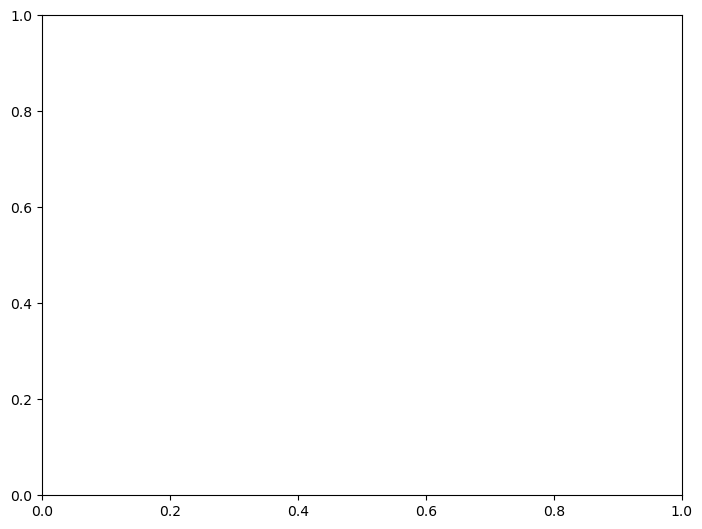

In [ ]:
gbmg = bmg(G, mode="strong")
nodes_colors = [G.nodes[v].get("color", "grey") for v in gbmg.nodes()]

nx.draw(gbmg, nx.circular_layout(gbmg), node_color=nodes_colors, with_labels=True)